<a href="https://colab.research.google.com/github/hanihayes/AI-OPs/blob/main/Linear_Regression_on_Bostonhousing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===============================
# 1. IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.formula.api as smf

In [ ]:
# 2. LOAD DATA
# ===============================
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)


In [ ]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


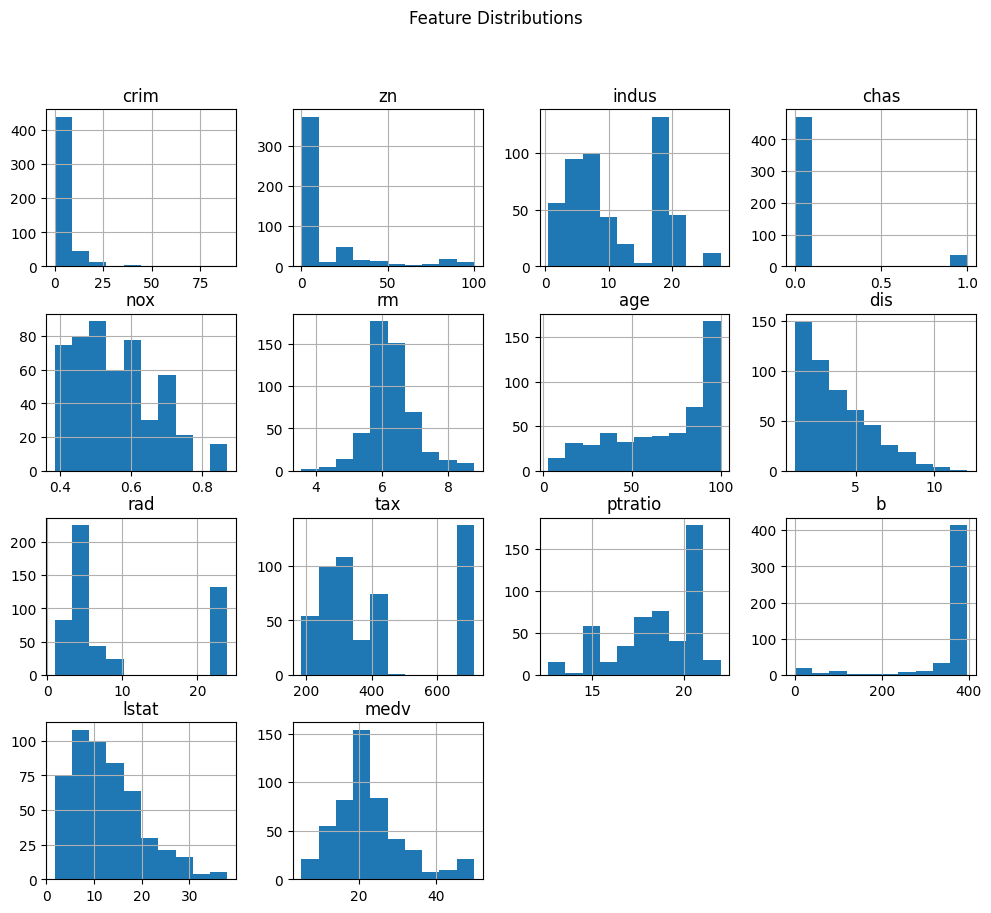

In [ ]:
# 3. EDA
# ===============================
# Histogram
df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

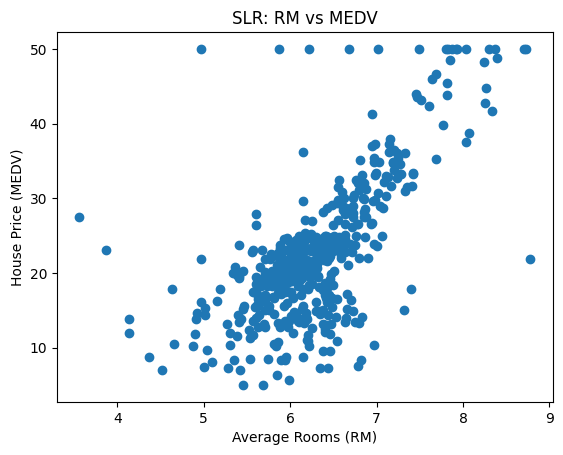

In [ ]:
# Scatter plot (SLR relationship)
plt.scatter(df['rm'], df['medv'])
plt.xlabel("Average Rooms (RM)")
plt.ylabel("House Price (MEDV)")
plt.title("SLR: RM vs MEDV")
plt.show()


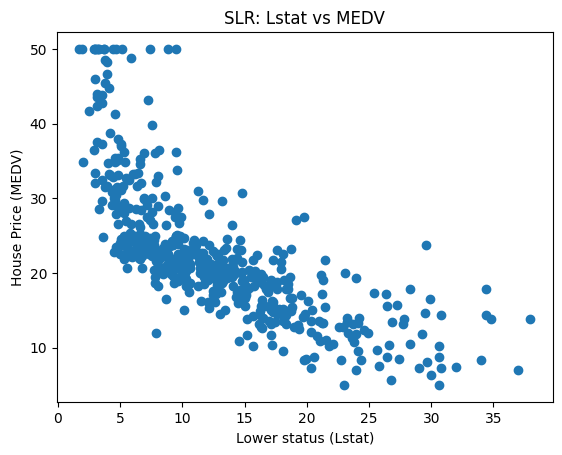

In [ ]:
# Scatter plot (SLR relationship)
plt.scatter(df['lstat'], df['medv'])
plt.xlabel("Lower status (Lstat)")
plt.ylabel("House Price (MEDV)")
plt.title("SLR: Lstat vs MEDV")
plt.show()

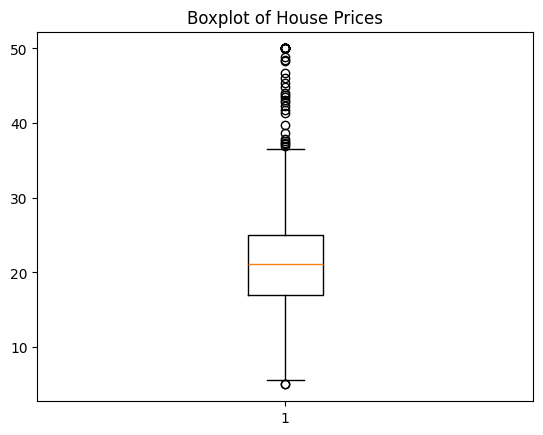

In [ ]:
# Boxplot (outliers)
plt.boxplot(df['medv'])
plt.title("Boxplot of House Prices")
plt.show()


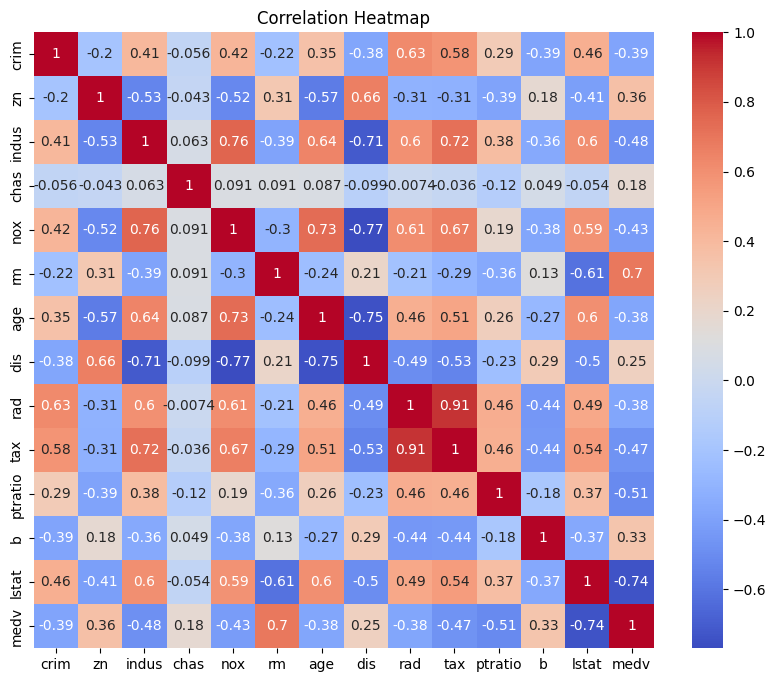

In [ ]:
# 4. HEATMAP (CORRELATION)
# ===============================
plt.figure(figsize=(10,8))
corr = df.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
# 5. SIMPLE LINEAR REGRESSION (SLR)
# ===============================
X_slr = df[['rm']]
y = df['medv']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_slr, y, test_size=0.3, random_state=565)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((354, 1), (152, 1), (354,), (152,))

In [ ]:
slr = LinearRegression()
slr.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred_slr = slr.predict(X_test)
y_pred_slr

array([19.54976259, 18.31258722, 19.15813873, 41.20478186, 23.77752015,
       16.65708636, 21.55238459, 24.63197221, 23.60840985, 21.50788188,
       25.45972264, 21.1963629 , 17.4670357 , 27.40004084, 19.63876801,
       30.16810948, 19.14033765, -1.64242849, 17.24452215, 19.78117669,
        8.0680631 , 17.94766499, 13.58639929, 30.5508328 , 21.40997592,
       17.92096336, 16.78169395, 20.98274989, 17.67174818, 27.66705711,
       23.7241169 , 16.25656196, 35.07230826, 30.61313659, 24.97909336,
       24.38275703, 21.14295965, 19.1314371 , 23.16338274, 23.6618131 ,
       15.19739743, 25.34401559, 29.18014929, 16.23876088, 10.3020992 ,
       27.29323434, 25.219408  , 21.21416399, 24.14244238, 28.53040971,
       23.40369738, 21.78379869, 16.19425816, 29.89219267, 20.92044609,
       18.44609535, 20.80473904, 16.75499233, 22.82516213, 21.50788188,
       26.52778771, 25.62883294, 23.37699575, 14.96598333, 17.63614601,
       21.86390357, 22.21992526, 26.54558879, 28.75292327, 20.63

In [ ]:
print("\nSLR Results")
print("\nSLR Results")
print("R2:", r2_score(y_test, y_pred_slr))


SLR Results

SLR Results
R2: 0.5525286822355802


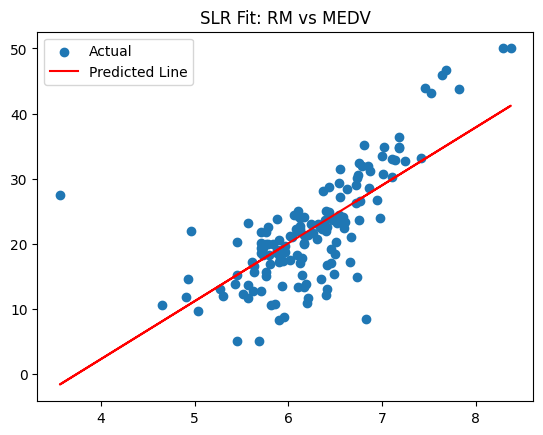

In [ ]:
# Regression line visualization
plt.scatter(X_test, y_test, label="Actual")
plt.plot(X_test, y_pred_slr, color='red', label="Predicted Line")
plt.title("SLR Fit: RM vs MEDV")
plt.legend()
plt.show()


# Multiple Linear Regression Model

In [ ]:
# 6. MULTIPLE LINEAR REGRESSION (MLR)
# ===============================
X_mlr = df[['rm', 'lstat', 'ptratio']]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_mlr, y, test_size=0.3, random_state=42)

In [ ]:
mlr = LinearRegression()
mlr.fit(X_train, y_train)
y_pred_mlr = mlr.predict(X_test)
y_pred_mlr

array([26.92298627, 30.93686434, 16.47934188, 25.25409179, 18.28052198,
       22.71776451, 17.48030837, 12.67868396, 20.65299142, 19.72674849,
       19.62053908, 21.39117368, -1.63888554, 22.28305258, 19.5334365 ,
       24.73953404, 17.1762308 ,  3.83959545, 39.02235903, 17.25781087,
       25.90189855, 27.47962656, 11.74316928, 23.53277967, 17.93698432,
       13.86981688, 22.65619649, 19.32774678, 18.15760126, 18.82706414,
       19.72132643, 25.49788496, 25.14274849, 18.4146037 , 14.50579644,
       21.30312278, 32.36532273, 20.91382657, 20.20888187, 24.82872147,
       12.74319123, 28.21994868, 39.52761971, 18.8078418 , 26.03183697,
       15.77223641, 14.27426728, 26.09480414, 18.29649761, 31.22324968,
       23.74269632, 33.559009  , 16.01682884, 25.67415581, 38.30791834,
       22.41596988, 18.34605716, 30.13739458, 24.81027677, 15.41857328,
       25.51195584, 32.09021934, 30.05047579, 17.23144792, 28.34222612,
       11.86980665, 19.1480674 , 25.75429805, 29.12514764, 15.79

In [ ]:
print("\nMLR Results")
print("R2:", r2_score(y_test, y_pred_mlr))


MLR Results
R2: 0.650904156861472


In [ ]:
# Coefficients
coef_df = pd.DataFrame({
    "Feature": X_mlr.columns,
    "Coefficient": mlr.coef_
})
print(coef_df)

   Feature  Coefficient
0       rm     4.461626
1    lstat    -0.608150
2  ptratio    -0.862905


In [ ]:
# 7. PREDICTIONS TABLE
# ===============================
pred_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_mlr
})

pred_df.head()


,Actual,Predicted
0,23.6,26.922986
1,32.4,30.936864
2,13.6,16.479342
3,22.8,25.254092
4,16.1,18.280522


# Method II

In [ ]:
# ===============================
# 10. OLS MODEL (STATISTICAL VIEW)
# ===============================
ols_model = smf.ols(formula="medv ~ rm + lstat + ptratio",data=df).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.679
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     353.3
Date:                Sat, 16 May 2026   Prob (F-statistic):          2.69e-123
Time:                        07:32:48   Log-Likelihood:                -1553.0
No. Observations:                 506   AIC:                             3114.
Df Residuals:                     502   BIC:                             3131.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     18.5671      3.913      4.745      0.0